In [1]:
# ==========================================
# Retail Demand Forecasting Project
# Import Required Libraries
# ==========================================

# Used for reading and manipulating datasets
import pandas as pd

# Used for numerical operations
import numpy as np

# Used for plotting graphs
import matplotlib.pyplot as plt

# Used for attractive statistical graphs
import seaborn as sns

# Used for converting categorical values into numbers
from sklearn.preprocessing import LabelEncoder

# Set graph style
plt.style.use("ggplot")

# Display graphs inside Jupyter Notebook
%matplotlib inline

c:\Users\dhara\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\dhara\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# ==========================================
# Load Dataset
# ==========================================

# Read the CSV file
data = pd.read_csv("retail_sales.csv")

# Print success message
print("Dataset Loaded Successfully!")

# Display first five rows
data.head()

Dataset Loaded Successfully!


,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [3]:
# ==========================================
# Dataset Shape
# ==========================================

# Print number of rows and columns

print("Number of Rows :", data.shape[0])

print("Number of Columns :", data.shape[1])

Number of Rows : 4565000
Number of Columns : 8


In [4]:
# ==========================================
# Dataset Information
# ==========================================

# Display column names, data types and non-null values

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      str    
 1   store_id  str    
 2   item_id   str    
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 385.9 MB


In [5]:
# ==========================================
# Display First Five Records
# ==========================================

data.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [6]:
# ==========================================
# Display Last Five Records
# ==========================================

data.tail()

,date,store_id,item_id,sales,price,promo,weekday,month
4564995,2023-12-27,store_50,item_50,28,64.10,1,2,12
4564996,2023-12-28,store_50,item_50,15,80.12,0,3,12
4564997,2023-12-29,store_50,item_50,12,80.12,0,4,12
4564998,2023-12-30,store_50,item_50,11,80.12,0,5,12
4564999,2023-12-31,store_50,item_50,10,80.12,0,6,12


In [7]:
# ==========================================
# Statistical Summary
# ==========================================

data.describe()

,sales,price,promo,weekday,month
count,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06
mean,2.926466e+01,5.399323e+01,9.999869e-02,3.001643e+00,6.523549e+00
std,1.500996e+01,2.578461e+01,2.999983e-01,1.999315e+00,3.448534e+00
min,0.000000e+00,8.020000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.800000e+01,3.197000e+01,0.000000e+00,1.000000e+00,4.000000e+00
50%,2.700000e+01,5.352000e+01,0.000000e+00,3.000000e+00,7.000000e+00
75%,3.800000e+01,7.536000e+01,0.000000e+00,5.000000e+00,1.000000e+01
max,1.390000e+02,9.999000e+01,1.000000e+00,6.000000e+00,1.200000e+01


In [8]:
# ==========================================
# Check Missing Values
# ==========================================

data.isnull().sum()

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [9]:
# ==========================================
# Remove Missing Values
# ==========================================

# Remove rows containing null values

data = data.dropna()

# Print new dataset size

print(data.shape)

(4565000, 8)


In [10]:
# ==========================================
# Convert Date into Datetime Format
# ==========================================

# Convert string into datetime format

data["date"] = pd.to_datetime(data["date"])

# Display first five rows

data.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [11]:
# ==========================================
# Create New Features
# ==========================================

# Extract Year

data["year"] = data["date"].dt.year

# Extract Month

data["month"] = data["date"].dt.month

# Extract Day

data["day"] = data["date"].dt.day

# Extract Weekday

data["weekday"] = data["date"].dt.weekday

# Display first five rows

data.head()

,date,store_id,item_id,sales,price,promo,weekday,month,year,day
0,2019-01-01,store_1,item_1,41,21.30,0,1,1,2019,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1,2019,2
2,2019-01-03,store_1,item_1,39,21.30,0,3,1,2019,3
3,2019-01-04,store_1,item_1,35,21.30,0,4,1,2019,4
4,2019-01-05,store_1,item_1,51,17.04,1,5,1,2019,5


In [12]:
# ==========================================
# Label Encoding
# ==========================================

# Create LabelEncoder object

encoder = LabelEncoder()

# Convert Store IDs into numbers

data["store_id"] = encoder.fit_transform(data["store_id"])

# Convert Item IDs into numbers

data["item_id"] = encoder.fit_transform(data["item_id"])

# Display first five rows

data.head()

,date,store_id,item_id,sales,price,promo,weekday,month,year,day
0,2019-01-01,0,0,41,21.30,0,1,1,2019,1
1,2019-01-02,0,0,53,21.30,0,2,1,2019,2
2,2019-01-03,0,0,39,21.30,0,3,1,2019,3
3,2019-01-04,0,0,35,21.30,0,4,1,2019,4
4,2019-01-05,0,0,51,17.04,1,5,1,2019,5


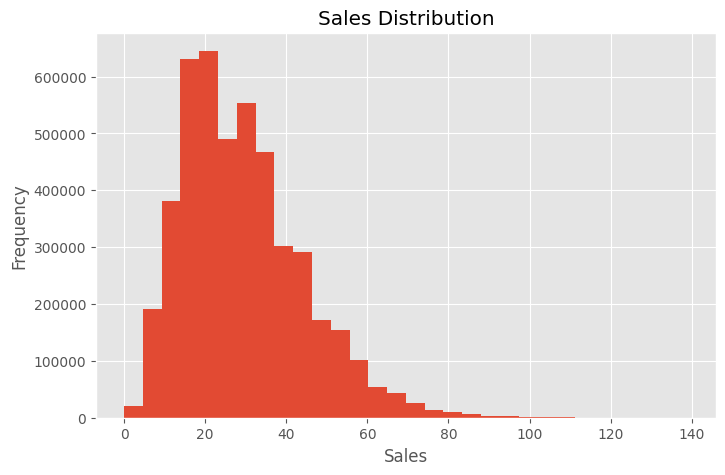

In [13]:
# ==========================================
# Sales Distribution
# ==========================================

plt.figure(figsize=(8,5))

plt.hist(data["sales"], bins=30)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

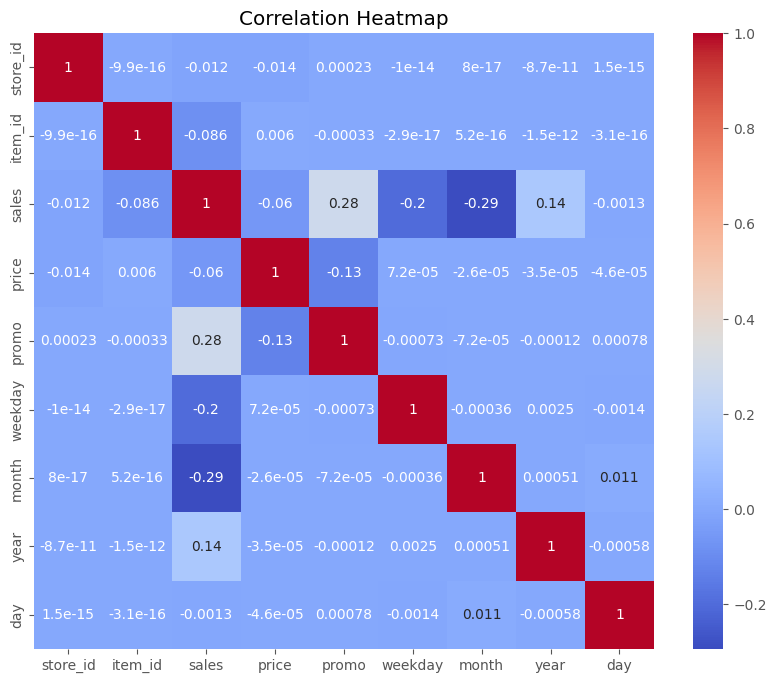

In [14]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [15]:
# ==========================================
# Save Cleaned Dataset
# ==========================================

# Save processed dataset

data.to_csv(
    "retail_sales_cleaned.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully!")

Cleaned Dataset Saved Successfully!
